# ***Système Intelligent de Prédiction du Diabète***

### Importer les bibliothèques

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Importer le dataset

In [8]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Taille du dataset

In [9]:
df.shape

(768, 9)

### Informations générales

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Statistiques descriptives

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Vérification des valeurs manquantes

In [12]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Vérifier les faux zéros

In [13]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


### Remplacer les faux zéros

In [14]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [15]:
for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [16]:
df.duplicated().sum()

np.int64(0)

### Countplot de Outcome

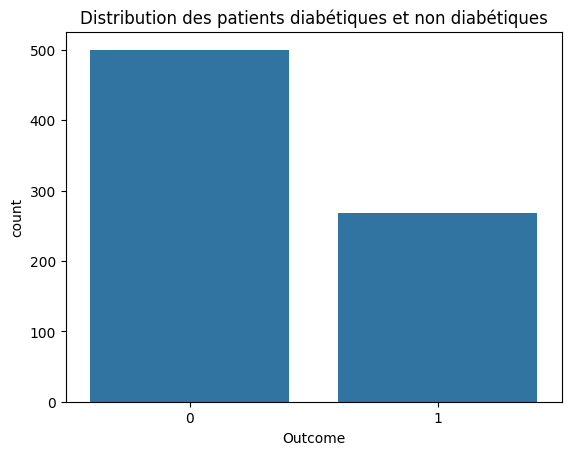

In [17]:
sns.countplot(x='Outcome', data=df)
plt.title("Distribution des patients diabétiques et non diabétiques")
plt.show()

### Histogramme de Glucose

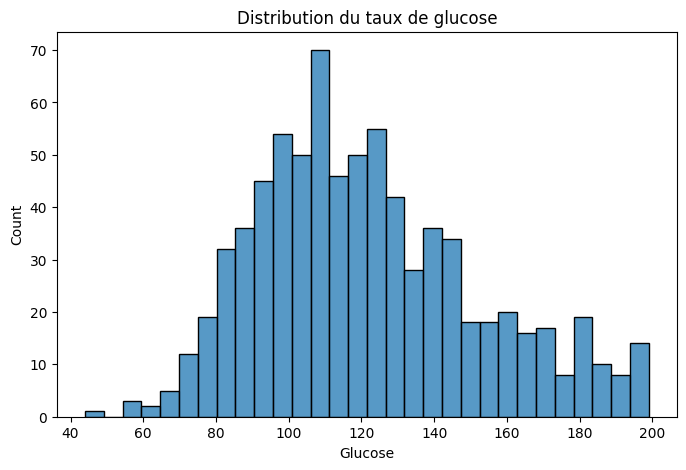

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Glucose'], bins=30)
plt.title("Distribution du taux de glucose")
plt.show()

### Heatmap de corrélation

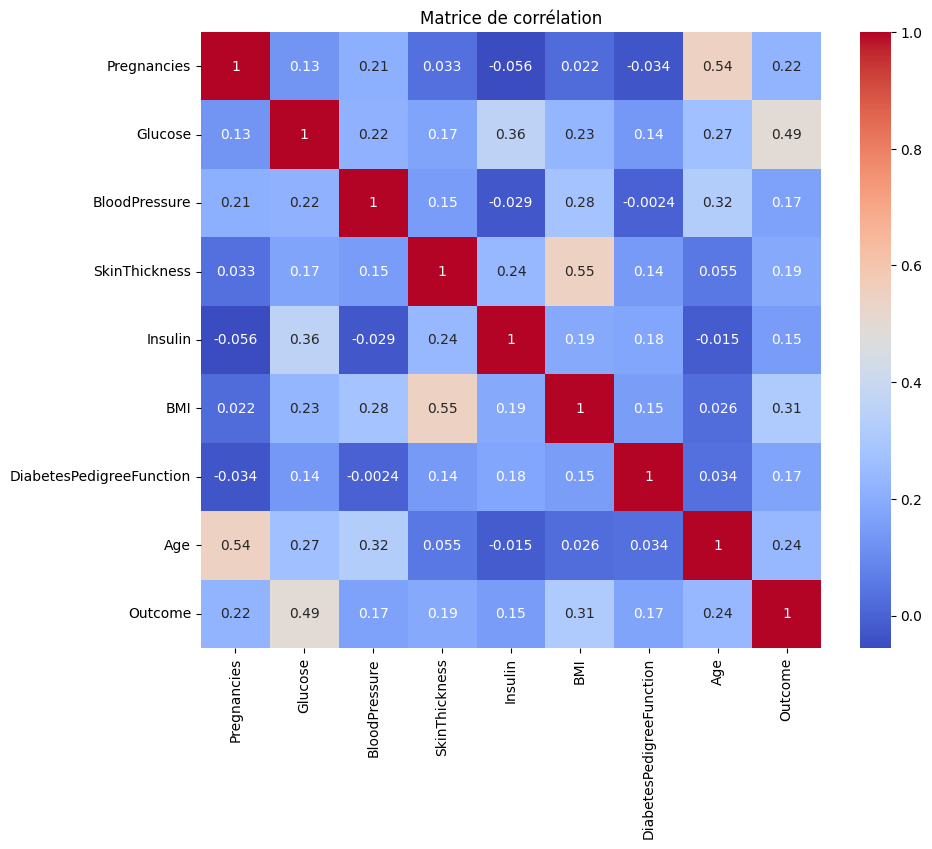

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

### Boxplot BMI

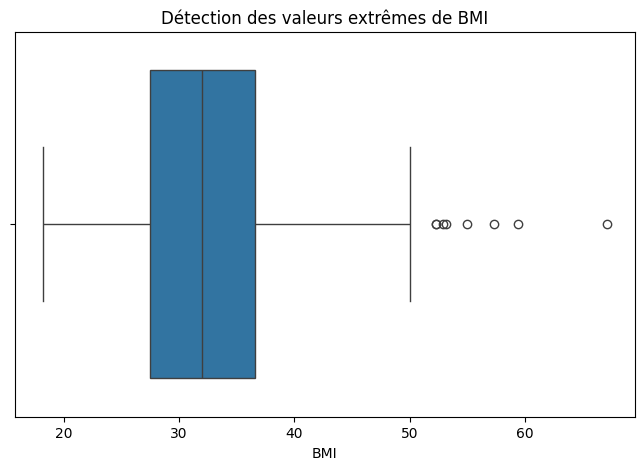

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['BMI'])
plt.title("Détection des valeurs extrêmes de BMI")
plt.show()

### Séparer X et y

In [21]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### StandardScaler

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Création du modèle ANN

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Entraînement du modèle

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4481 - loss: 0.7322 - val_accuracy: 0.6016 - val_loss: 0.6889
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5764 - loss: 0.6864 - val_accuracy: 0.6667 - val_loss: 0.6646
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6619 - loss: 0.6541 - val_accuracy: 0.6911 - val_loss: 0.6413
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7291 - loss: 0.6238 - val_accuracy: 0.7073 - val_loss: 0.6192
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7413 - loss: 0.5938 - val_accuracy: 0.7236 - val_loss: 0.5912
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7475 - loss: 0.5641 - val_accuracy: 0.7317 - val_loss: 0.5614
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7536 - loss: 0.5330 - val_accuracy: 0.7317 - val_loss: 0.5352
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7739 - loss: 0.5069 - val_accuracy: 0.7561 - val_loss

### Prédiction

In [26]:
pred = model.predict(X_test)
pred[:10]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([[0.3427016 ],
       [0.20364481],
       [0.13407823],
       [0.20887493],
       [0.46817616],
       [0.46824718],
       [0.02717329],
       [0.45955378],
       [0.58374184],
       [0.5724378 ]], dtype=float32)

### Transformer en 0 / 1

In [27]:
pred = (pred > 0.5).astype(int).flatten()
pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

### Classification Report

In [28]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82        99
           1       0.71      0.53      0.60        55

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



### Confusion Matrix

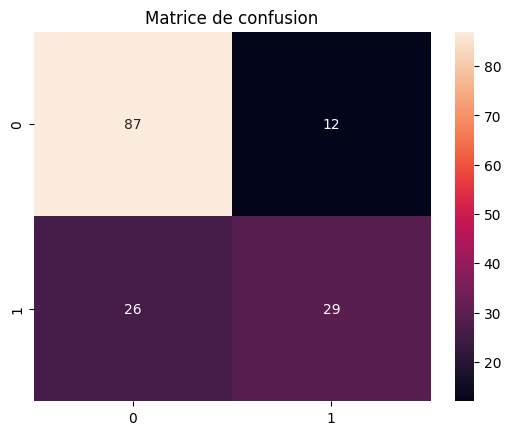

In [29]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matrice de confusion")
plt.show()

### Accuracy Score

In [30]:
print(accuracy_score(y_test, pred))

0.7532467532467533


### Decision Layer


In [31]:
def diabetes_decision(score):
    if score < 0.3:
        return "Risque faible - Suivi normal"

    elif score < 0.7:
        return "Risque moyen - Consultation recommandée"

    else:
        return "Risque élevé - Consultation urgente"


example_score = 0.82

print("Score de risque :", example_score)
print("Décision :", diabetes_decision(example_score))

Score de risque : 0.82
Décision : Risque élevé - Consultation urgente


### Graphiques Accuracy / Loss

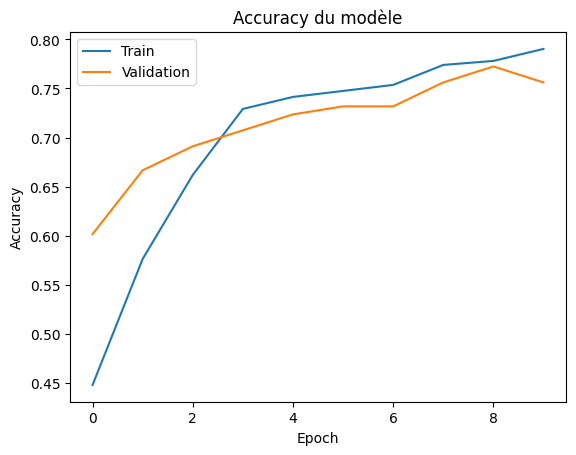

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy du modèle")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

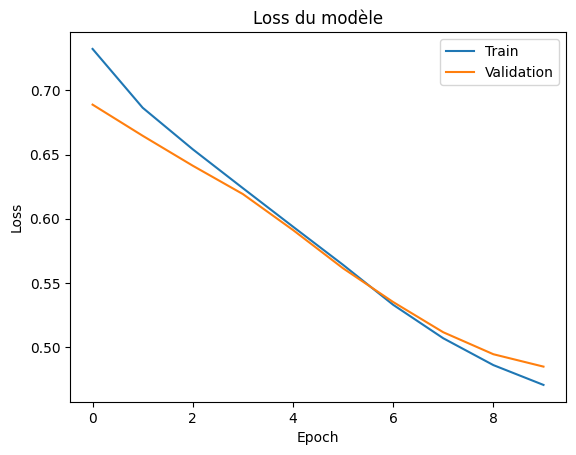

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss du modèle")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])

plt.show()

### Sauvegarder le modèle

In [34]:
model.save("diabetes_model.h5")